In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your exported CSV (change path to your file)
df = pd.read_csv("/content/14_Nov_Metric3_IdleFailCount_sheet - Form Responses 1 (1).csv")

# --- Rename scenes for readability ---
rename_map = {
    "Main": "Level 1",
    "MainForLevel2": "Level 2 (Normal Maze)",
    "Level2_DarkMaze": "Level 2 (Dark Maze)",
    "MainForLevel3": "Level 3"
}
df["sceneName"] = df["sceneName"].replace(rename_map)


# Convert timestamps and numerics
df["ts"] = pd.to_datetime(df["ts"], errors="coerce")
num_cols = [
    "levelIndex", "attemptIndex", "idleThresholdSec",
    "idleDeathCountThisLevel", "timeSinceLevelStartSec", "submitOnNth"
]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Clean scene names for grouping
df["sceneName"] = df["sceneName"].fillna("Unknown").astype(str)
print(df.head())

            Timestamp  Column 1                               ts sessionId  \
0  11/14/2025 1:49:20       NaN 2025-11-14 09:49:19.639000+00:00       NaN   
1  11/14/2025 1:51:45       NaN 2025-11-14 09:51:44.463000+00:00       NaN   
2  11/14/2025 1:55:27       NaN 2025-11-14 09:55:27.238000+00:00       NaN   
3  11/14/2025 1:58:55       NaN 2025-11-14 09:58:54.366000+00:00       NaN   
4  11/14/2025 2:00:40       NaN 2025-11-14 10:00:39.585000+00:00       NaN   

               sceneName  levelIndex  attemptIndex  eventType  \
0                Level 3          -1            -1  IdleDeath   
1                Level 3          -1            -1  IdleDeath   
2                Level 3          -1            -1  IdleDeath   
3  Level 2 (Normal Maze)          -1            -1  IdleDeath   
4                Level 3          -1            -1  IdleDeath   

   idleThresholdSec  idleDeathCountThisLevel  timeSinceLevelStartSec  \
0                 3                        1                   9.491

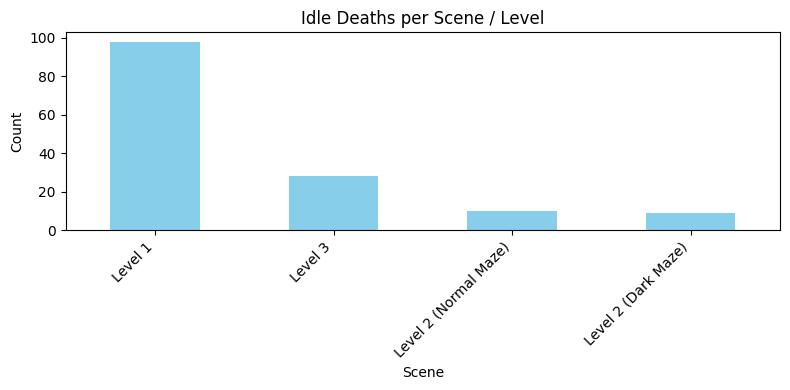

In [ ]:
scene_counts = df.groupby("sceneName").size().sort_values(ascending=False)
scene_counts.plot(kind="bar", color="skyblue", figsize=(8,4))
plt.title("Idle Deaths per Scene / Level")
plt.xlabel("Scene")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


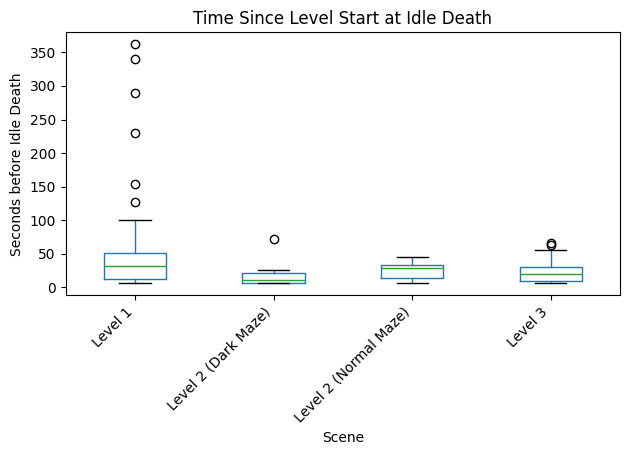

In [ ]:
df.boxplot(column="timeSinceLevelStartSec", by="sceneName", grid=False)
plt.title("Time Since Level Start at Idle Death")
plt.suptitle("")  # remove automatic extra title
plt.xlabel("Scene")
plt.ylabel("Seconds before Idle Death")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

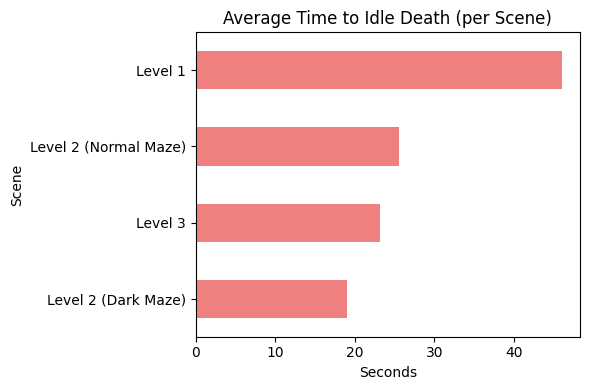

In [ ]:
avg_idle = df.groupby("sceneName")["timeSinceLevelStartSec"].mean().sort_values()
avg_idle.plot(kind="barh", color="lightcoral", figsize=(6,4))
plt.title("Average Time to Idle Death (per Scene)")
plt.xlabel("Seconds")
plt.ylabel("Scene")
plt.tight_layout()
plt.show()
